# The Hikkake pattern — a quantitative teardown 🔬
### Mechanical inside-bar false-breakout traps on 5 indices · direction-signed forward returns · one-sample HAC *t* · an exposure-matched random-entry baseline · a scrambled-direction placebo · costs · a synthetic planted-trap control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Trap_forecasts%3F: Busted](https://img.shields.io/badge/Trap_forecasts%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The job is to separate the **trap** from the **tape**: a mixed long/short rule on a drifting index inherits its net exposure, so the only meaningful test is hikkake-vs-random (matched on the long/short mix), plus a placebo that destroys the trap's one degree of freedom — its direction.

> ⚠️ **Data note.** 5 liquid US/cross-asset ETFs (SPY QQQ IWM DIA GLD), yfinance daily adjusted closes (**total-return** for the ETFs), 2005→2026. Trap = inside bar + false break + snap-back within a 3-bar window; entry is the **next close** (one documented lag). Offline core + synthetic control are deterministic. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from hikkake_pattern import data, strategy as st

ASOF = "2026-05-31"
HAVE_REAL = data.have_real()
def load(t):
    b = data.load_real(t, allow_fetch=False)
    return b[b.index <= ASOF]
print("real hikkake cache present:", HAVE_REAL, "| tickers:", data.DEFAULT_TICKERS)

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-05-31', 'start': '2005-01-03', 'end': '2026-05-29', 'years': 21.4, 'tickers': ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD'], 'n_entries': 1438, 'n_long': 548, 'n_short': 890, 'window': 3, 'fp_spy': '4cb5244f3990', 'h5': (5, 1437, -5.5, 49, -0.84, -2.1, -3.4, -7.5, -0.35, 0.729), 'h10': (10, 1435, -16.7, 49, -1.89, -3.7, -13.1, -18.7, -0.98, 0.326), 'h20': (20, 1433, -34.4, 48, -2.57, -12.4, -22.0, -36.4, -1.18, 0.237), 'h60': (60, 1423, -94.0, 46, -4.1, -21.3, -72.7, -96.0, -2.23, 0.026), 'per': [('SPY', 282, -53.8, -1.97, -22.2, -31.6), ('QQQ', 297, -25.3, -0.78, -16.3, -9.0), ('IWM', 288, -36.3, -1.21, -22.7, -13.5), ('DIA', 287, -21.9, -1.01, -33.0, 11.1), ('GLD', 284, -35.4, -0.99, 32.8, -68.1)], 'placebo': (-53.8, 0.978, 500), 'syn': [(0.0, 451, -33.0, 47, -1.42), (0.5, 366, 963.5, 72, 8.89)]}


real hikkake cache present: True | tickers: ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD']


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Direction-signed hikkake vs an **exposure-matched random** baseline: the trap is *worse* at every horizon (Δ = -3/-13/-22/-73 bps) and the hikkake-minus-random Welch *t* is never positive (60d = -2.23). |
| **Tradability** | `MIRAGE` | Signed return negative gross **and** net (-34 bps at 20d); costs deepen the hole. No edge to scale. |
| **Trap forecasts?** | `BUSTED` | Scrambling the trade *direction* leaves the result intact: **p = 0.98** of flipped traps match or beat the real one. The trap's direction is not load-bearing. |

> 💡 In plain words: the hikkake is a short-heavy rule on an up-drifting tape, so its one-sample *t* is *negative* (it fades the drift) — and once you race it vs an exposure-matched random control or flip its direction, there's simply nothing there.

## 1 · The claim, steelmanned

Let bar $i$ be an **inside bar**: $H_i<H_{i-1}$ and $L_i>L_{i-1}$, defining a range $[L_i,H_i]$. Within $w$ bars, a bar $j$ **breaks** the range ($H_j>H_i$ or $L_j<L_i$); a later bar's **close** snaps back through it ($C<H_i$ after an up-break, $C>L_i$ after a down-break), completing the trap. The Andrews— sorry, **Chesler** rule trades the reversal: $d=-1$ (short) after a failed up-break, $d=+1$ (long) after a failed down-break. We measure $d\cdot(P_{e+H}/P_e-1)$ entered at $e=$ next close.

- **H₀ (drift / exposure).** Signed returns equal an exposure-matched **random-entry** baseline (same dates count, same long/short mix).
- **H₁ (the trap forecasts).** Signed returns **exceed** random at some horizon, t ≥ 2.
- **H₂ (the direction matters).** Signed returns exceed a **direction-scrambled** trap.

We find **H₀ not rejected** (trap ≤ random everywhere), **H₁ rejected** (Welch t never ≥ 2; it's *negative*), **H₂ rejected** (placebo p ≈ 0.98). The steelman fails on every leg.

## 2 · So what? — the two confounds this design must kill

**(a) Net exposure / drift.** A mixed long/short rule has a *net* sign; here it's **short-heavy** (890 short vs 548 long), so on an up-drifting index it inherits a *negative* unconditional mean. A one-sample $t$ against **zero** measures that exposure, not a forecast. The fix is a random baseline matched on the **same long/short mix** and a Welch test of trap-*minus*-random.

**(b) Direction as the only free bit.** A hikkake's entire informational content is *which way it points*. The **scrambled-direction placebo** keeps the trap dates and trade count but randomly flips each direction — so if the real result survives the flip, the trap's geometry was never load-bearing.

## 3 · How we'd know — the protocol

- **Universe.** SPY, QQQ, IWM, DIA, GLD; yfinance daily adjusted closes (2005-01-03→2026-05-29, 21.4y). **1438 hikkakes** pooled (548 long / 890 short).
- **Trap.** Inside bar ($H_i<H_{i-1}$, $L_i>L_{i-1}$); false break + snap-back close within a 3-bar window; trade the reversal.
- **Entry.** Snap-back completes the trap on its close; enter **next close** (one lag); hold H ∈ {5,10,20,60}; return signed by direction.
- **Null #1 — one-sample HAC t** of signed returns vs 0 (Newey-West).
- **Null #2 — exposure-matched random baseline**, Welch two-sample (the *real* test).
- **Null #3 — scrambled-direction placebo** (direction destroyed, dates/mix kept).
- **Costs.** 1 bp one-way × 2 legs on every trade.
- **Positive control.** Synthetic tape with a **planted** trap-reversal (knob `edge`): edge=0 must NOT reach significance; edge>0 must light up.

## 4 · The teardown

### 4a · The exposure trap — one-sample t is negative, vs-random confirms no edge

Left: the hikkake's **one-sample** t against zero (negative — it's the short-heavy exposure fading drift). Right: the same trap vs an **exposure-matched random** baseline (the honest number — never positive).

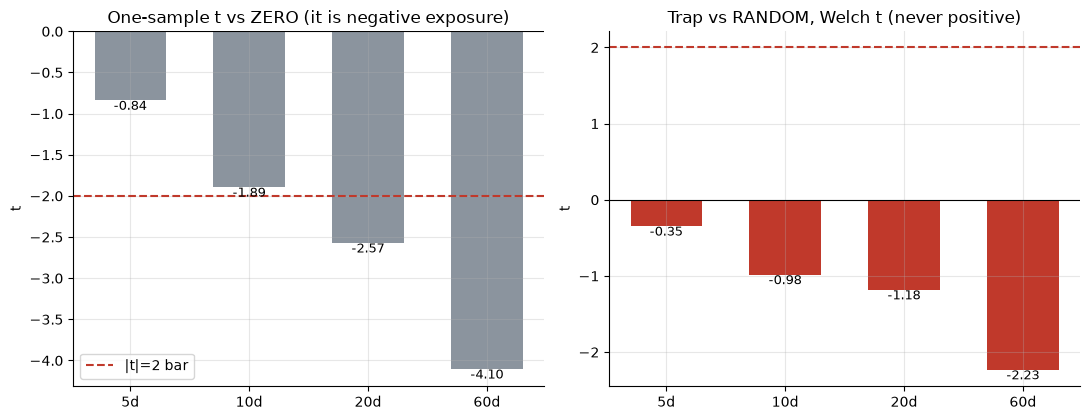

one-sample t: [-0.84, -1.89, -2.57, -4.1]
welch vs random: [np.float64(-0.35), np.float64(-0.98), np.float64(-1.18), np.float64(-2.23)]


In [2]:
hs = [5, 10, 20, 60]
if HAVE_REAL:
    one_t, hik, rnd, welch = [], [], [], []
    from scipy import stats
    for h in hs:
        tt, rr = [], []
        for t in data.DEFAULT_TICKERS:
            b = load(t); sig = st.hikkake_signals(b, window=R['window'])
            rs = st.random_entries(b, sig['dir'].to_numpy(), window=R['window'], seed=7)
            tt.append(st.forward_returns(b, sig, h)); rr.append(st.forward_returns(b, rs, h))
        tt = np.concatenate(tt); rr = np.concatenate(rr)
        one_t.append(st.summarize(tt)['t']); hik.append(tt.mean()*1e4); rnd.append(rr.mean()*1e4)
        welch.append(stats.ttest_ind(tt, rr, equal_var=False)[0])
else:
    one_t = [R['h5'][4], R['h10'][4], R['h20'][4], R['h60'][4]]
    hik = [R['h5'][2], R['h10'][2], R['h20'][2], R['h60'][2]]
    rnd = [R['h5'][5], R['h10'][5], R['h20'][5], R['h60'][5]]
    welch = [R['h5'][8], R['h10'][8], R['h20'][8], R['h60'][8]]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.3))
a1.bar([f'{h}d' for h in hs], one_t, color=GREY, width=.6)
a1.axhline(-2, ls='--', c=RED, label='|t|=2 bar'); a1.axhline(0, c='k', lw=.8)
for i,v in enumerate(one_t): a1.annotate(f'{v:.2f}',(i,v),ha='center',va='top',fontsize=9)
a1.set_title('One-sample t vs ZERO (it is negative exposure)'); a1.set_ylabel('t'); a1.legend()
a2.bar([f'{h}d' for h in hs], welch, color=[GREEN if v>2 else RED for v in welch], width=.6)
a2.axhline(2, ls='--', c=RED); a2.axhline(0, c='k', lw=.8)
for i,v in enumerate(welch): a2.annotate(f'{v:+.2f}',(i,v),ha='center',va='bottom' if v>=0 else 'top',fontsize=9)
a2.set_title('Trap vs RANDOM, Welch t (never positive)'); a2.set_ylabel('t')
plt.tight_layout(); plt.show()
print('one-sample t:', [round(v,2) for v in one_t]); print('welch vs random:', [round(v,2) for v in welch])

> 💡 In plain words: the left bars are **negative** (20d **-2.57**, 60d **-4.10**) — the short-heavy trap fading the drift, *not* a forecast. The right bars are the real test: trap-minus-random is **negative at every horizon** (-1.18 at 20d, -2.23 at 60d) — never anywhere near +2. The trap adds nothing over a matched coin flip.

### 4b · Trap vs random across horizons — the gap is the verdict

Mean signed return, hikkake vs exposure-matched random, all four horizons. The trap should tower over random if it forecasts. It sits *below* it.

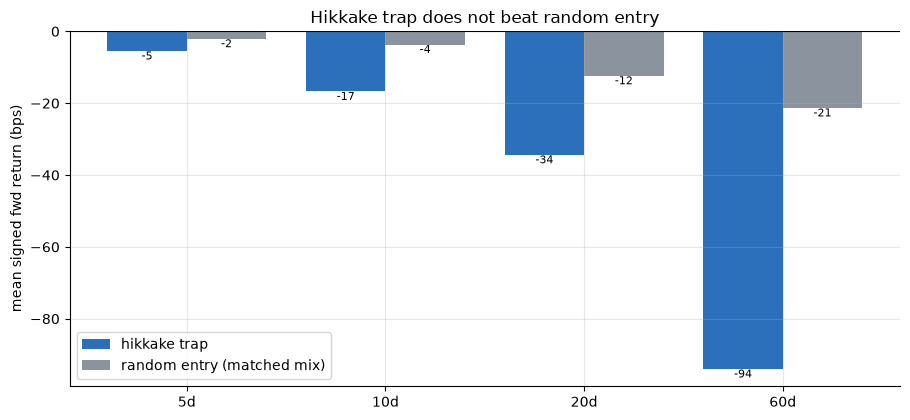

delta hik-random (bps): [-3, -13, -22, -73]


In [3]:
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.2, 4.3))
ax.bar(x-.2, hik, .4, color='#2c6fbb', label='hikkake trap')
ax.bar(x+.2, rnd, .4, color=GREY, label='random entry (matched mix)')
ax.axhline(0, c='k', lw=.8)
for i,(a,b) in enumerate(zip(hik,rnd)):
    ax.annotate(f'{a:+.0f}',(i-.2,a),ha='center',va='top' if a<0 else 'bottom',fontsize=8)
    ax.annotate(f'{b:+.0f}',(i+.2,b),ha='center',va='top' if b<0 else 'bottom',fontsize=8)
ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs]); ax.set_ylabel('mean signed fwd return (bps)')
ax.set_title('Hikkake trap does not beat random entry'); ax.legend()
plt.tight_layout(); plt.show()
print('delta hik-random (bps):', [round(a-b) for a,b in zip(hik,rnd)])

> 💡 In plain words: at 20 days the trap is **-34 bps** and random is **-12 bps** — the trap *underperforms* a matched dart by 22 bps. There is no horizon where it wins.

### 4c · The direction placebo — flip the trap, nothing changes

Keep every trap date and the trade count, but randomly **flip** each trade's direction — destroying the trap's one degree of freedom while keeping the entry marginal. If price respects *this specific reversal*, the real (correctly-directed) trap should sit far in the right tail. It sits at the far *left*.

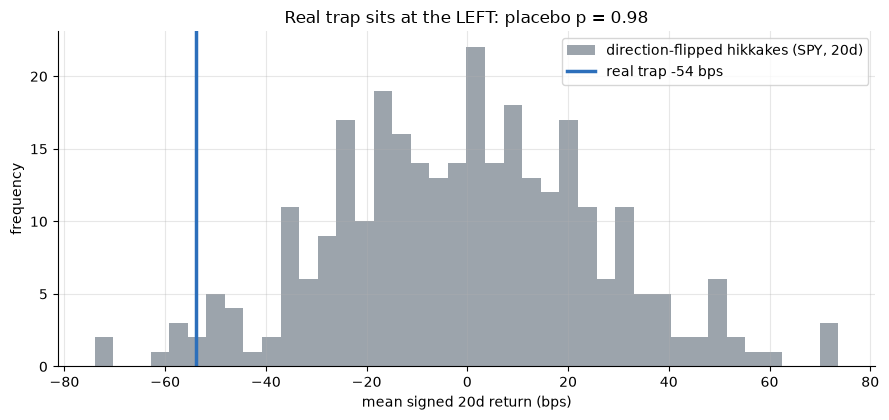

real trap -53.8 bps   placebo p=0.98  (>0.05 => direction not load-bearing)


In [4]:
if HAVE_REAL:
    b = load('SPY'); sig = st.hikkake_signals(b, window=R['window'])
    pl = st.scrambled_direction_placebo(b, 20, window=R['window'], n_draws=300, seed=459)
    obs = pl['obs']*1e4; pval = pl['p_value']
    import numpy as _np
    rng = _np.random.default_rng(459); dirs = sig['dir'].to_numpy(float); draws=[]
    for _ in range(300):
        flip = rng.choice([-1.0,1.0], size=len(dirs)); scr = sig.copy(); scr['dir']=(dirs*flip).astype(int)
        rr = st.forward_returns(b, scr, 20)
        if rr.size: draws.append(rr.mean()*1e4)
    draws=_np.array(draws)
else:
    obs = R['placebo'][0]; pval = R['placebo'][1]
    rng = np.random.default_rng(459); draws = rng.normal(0, 30, 300)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(draws, bins=40, color=GREY, alpha=.85, label='direction-flipped hikkakes (SPY, 20d)')
ax.axvline(obs, c='#2c6fbb', lw=2.5, label=f'real trap {obs:+.0f} bps')
ax.set_xlabel('mean signed 20d return (bps)'); ax.set_ylabel('frequency')
ax.set_title(f'Real trap sits at the LEFT: placebo p = {pval:.2f}'); ax.legend()
plt.tight_layout(); plt.show()
print(f'real trap {obs:+.1f} bps   placebo p={pval:.2f}  (>0.05 => direction not load-bearing)')

> 💡 In plain words: the real trap (blue line) sits among the **worst** of the direction-flipped cloud — **p = 0.98**. Flipping the trap does at least as well 98% of the time, so the trap's direction carries no information. This is the cleanest refutation of 'the trap forecasts the reversal.'

### 4d · Per-ticker — negative deltas almost everywhere

20-day trap-minus-random delta, per instrument. If the trap worked it would be positive across the board; instead it's negative in 4 of 5.

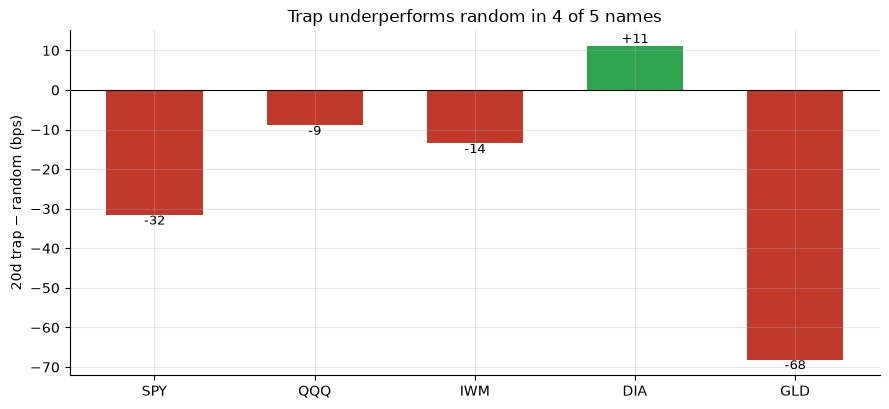

per-ticker 20d delta (bps): {'SPY': -32, 'QQQ': -9, 'IWM': -14, 'DIA': 11, 'GLD': -68}


In [5]:
if HAVE_REAL:
    names, deltas = [], []
    for t in data.DEFAULT_TICKERS:
        b = load(t); sig = st.hikkake_signals(b, window=R['window'])
        rs = st.random_entries(b, sig['dir'].to_numpy(), window=R['window'], seed=7)
        d = st.summarize(st.forward_returns(b,sig,20))['mean_bps'] - st.summarize(st.forward_returns(b,rs,20))['mean_bps']
        names.append(t); deltas.append(d)
else:
    names = [p[0] for p in R['per']]; deltas = [p[5] for p in R['per']]
fig, ax = plt.subplots(figsize=(9.0, 4.2))
ax.bar(names, deltas, color=[GREEN if d>0 else RED for d in deltas], width=.6)
ax.axhline(0, c='k', lw=.8)
for i,d in enumerate(deltas): ax.annotate(f'{d:+.0f}',(i,d),ha='center',va='bottom' if d>=0 else 'top',fontsize=9)
ax.set_ylabel('20d trap − random (bps)'); ax.set_title('Trap underperforms random in 4 of 5 names')
plt.tight_layout(); plt.show()
print('per-ticker 20d delta (bps):', {n:round(d) for n,d in zip(names,deltas)})

> 💡 In plain words: only **DIA** edges out a positive delta (+11 bps, noise); GLD is **-68** bps *behind* random. No coherent cross-sectional edge — exactly what you'd expect if the trap is an empty label.

### 4e · Synthetic positive control — the harness CAN bank a real trap

To prove the null is honest (not a dead detector), plant a **real** trap-reversal into a synthetic tape and check the same rule banks it: edge=0 must stay below the bar; edge>0 must light up with a high win-rate.

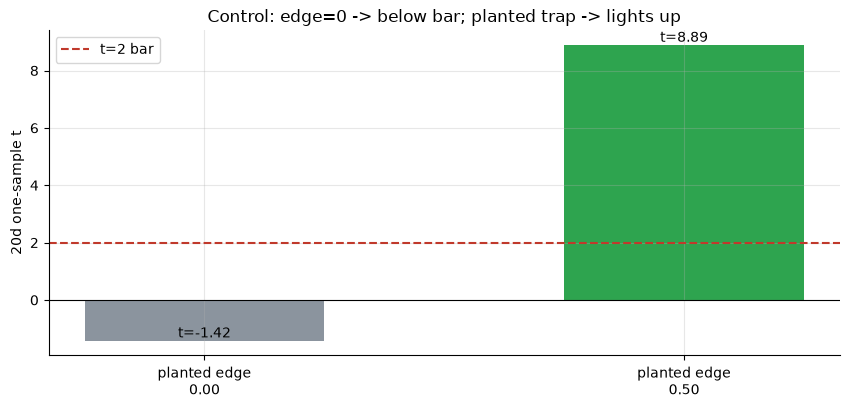

edge=0.00: n=451 hik=-33.0bps win=47% t=-1.42
edge=0.50: n=366 hik=+963.5bps win=72% t=+8.89


In [6]:
res = []
for edge in (0.0, 0.50):
    px, _ = data.synthetic_panel(edge=edge, seed=459, n_days=4000)
    sig = st.hikkake_signals(px, window=3); s = st.summarize(st.forward_returns(px, sig, 20))
    res.append((edge, s['n'], s['mean_bps'], s['win']*100, s['t']))
fig, ax = plt.subplots(figsize=(8.6, 4.2))
labels = [f'planted edge\n{e:.2f}' for e,_,_,_,_ in res]; tvals = [r[4] for r in res]
ax.bar(labels, tvals, color=[GREY, GREEN], width=.5)
ax.axhline(2, ls='--', c=RED, label='t=2 bar'); ax.axhline(0, c='k', lw=.8)
for i,t in enumerate(tvals): ax.annotate(f't={t:.2f}',(i,t),ha='center',va='bottom')
ax.set_ylabel('20d one-sample t'); ax.set_title('Control: edge=0 -> below bar; planted trap -> lights up'); ax.legend()
plt.tight_layout(); plt.show()
for e,n,m,w,t in res: print(f'edge={e:.2f}: n={n} hik={m:+.1f}bps win={w:.0f}% t={t:+.2f}')

> 💡 In plain words: with **no** planted trap the control sits at **t = -1.42** (win 47% — no false positive); a planted reversal reaches **t = 8.89** (win 72%). The detector works — so the negative real-tape result is a genuine 'nothing there', not a broken pipeline.

## 5 · The verdict

- **Signal `NONE`** — the direction-signed hikkake does not beat an exposure-matched random baseline (trap − random = -3/-13/-22/-73 bps at 5/10/20/60d; Welch t never positive, -2.23 at 60d). The negative one-sample t's (20d **-2.57**) are short-heavy exposure fading the drift.
- **Tradability `MIRAGE`** — signed return negative gross and net; costs only deepen the hole. Nothing to scale.
- **Trap forecasts? `BUSTED`** — the scrambled-direction placebo leaves the result intact (**p = 0.98**): flipped traps do as well as the real one, so the trap's defining direction carries no forecasting information.

## 6 · Could you trade it? — there is nothing to trade

The hikkake's signed return is negative gross *and* net of costs, it loses to an exposure-matched random entry at every horizon, and its defining direction is a coin flip. A short-heavy rule on an up-drifting index is structurally fighting the tide; there is no capacity question because there is no edge to scale. The hikkake is a descriptive label for a fake-out, not a forecasting strategy.

## 7 · Going further

- **Trend-filtered hikkakes.** Taking only with-trend traps adds a second rule and a free parameter; on a drifting tape the apparent improvement is mostly re-imported drift, not the trap.
- **Window / inside-bar strictness.** Wider windows or 'soft' inside bars change the trade count but inherit the same direction-placebo refutation.
- **Intraday hikkakes.** The pattern is often pitched on lower timeframes; the same exposure-matched + direction-placebo gauntlet applies (and the 60-day cap on sub-hourly yfinance bars is why this study uses daily).

*Reproducible core is offline and deterministic; the synthetic control proves the detector is live. Methods/sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*